# Hierarchiczna analiza skupień metodą Warda

Notebook implementuje aglomeracyjną analizę skupień **od zera (bez scipy.cluster.hierarchy)** dla danych ciągłych z:
- metryką: odległość euklidesowa,
- łączeniem klastrów: metodą Warda (rekurencja Lance-Williamsa),
- parametrem `n_clusters` sterującym liczbą grup,
- własną implementacją cięcia drzewa na klastry (`fcluster`) i rysowania dendrogramu (`dendrogram`),
- dendrogramem z podziałem na grupy i wektorem etykiet punktów.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'

## Implementacja od zera

Dla macierzy danych $X \in \mathbb{R}^{n \times p}$ algorytm startuje od $n$ jednoelementowych grup
i iteracyjnie łączy parę klastrów, która najmniej zwiększa wariancję wewnątrzgrupową (kryterium Warda).

Cała logika jest napisana od podstaw przy użyciu samego NumPy, bez `scipy.cluster.hierarchy`:

1. **`ward_linkage(X)`** — buduje macierz łączeń `Z` (w formacie zgodnym ze scipy: `[idx1, idx2, distance, count]`).
   W każdym kroku wybierana jest para aktywnych klastrów $a, b$ o najmniejszej odległości Warda, a po ich połączeniu
   odległości do pozostałych klastrów aktualizowane są wzorem **Lance–Williamsa** dla metody Warda:

   $$d(a \cup b, c)^2 = \frac{(n_a + n_c)\, d(a,c)^2 + (n_b + n_c)\, d(b,c)^2 - n_c \, d(a,b)^2}{n_a + n_b + n_c}$$

   gdzie $n_a, n_b, n_c$ to liczności klastrów. Złożoność: $O(n^3)$ czasu, $O(n^2)$ pamięci — wystarczające
   dla danych demonstracyjnych i małych/średnich zbiorów (setki punktów).

2. **`fcluster_maxclust(Z, n_clusters)`** — odpowiednik `scipy.cluster.hierarchy.fcluster(..., criterion='maxclust')`.
   Stosuje tylko pierwsze `n_samples - n_clusters` połączeń z `Z` (czyli zatrzymuje się tuż przed ostatnimi,
   najwyższymi połączeniami) i odczytuje przynależność punktów do grup przy pomocy struktury **Union-Find**.
   Numeracja etykiet (1..k) jest własną, deterministyczną konwencją (rosnąco wg najmniejszego indeksu punktu
   w grupie) — sama wartość liczbowa etykiety jest umowna, podobnie jak w scipy; liczy się wyłącznie podział
   punktów na grupy.

3. **`plot_dendrogram(Z, ...)`** — rysuje dendrogram na podstawie `Z`: pozycja x liścia wynika z kolejności
   DFS po drzewie (bez przecinających się gałęzi), pozycja y węzła wewnętrznego to wysokość połączenia
   (`Z[:, 2]`), a każde połączenie rysowane jest jako kształt „U”.

Do wyznaczenia poziomu cięcia dendrogramu nadal używamy pomocniczej funkcji `_cut_threshold_for_k_clusters`,
która na podstawie posortowanych wysokości połączeń w `Z` wyznacza próg odpowiadający zadanej liczbie grup.


In [2]:
def ward_linkage(X: np.ndarray) -> np.ndarray:
    """
    Hierarchiczna aglomeracja metodą Warda - implementacja od zera (bez scipy).

    Zwraca macierz Z w formacie zgodnym ze scipy.cluster.hierarchy.linkage:
    wiersz i = [idx1, idx2, distance, n_elementow_w_nowym_klastrze],
    gdzie idx1 < idx2. Indeksy < n_samples odnoszą się do oryginalnych
    punktów, a indeksy >= n_samples - do klastrów utworzonych we
    wcześniejszych krokach (klaster powstały w kroku i ma indeks n_samples + i).

    Algorytm: klasyczna rekurencja Lance-Williamsa dla metody Warda,
    z pełną aktualizacją macierzy odległości po każdym połączeniu
    (O(n^3) czasu, O(n^2) pamięci).
    """
    X = np.asarray(X, dtype=float)
    n_samples = X.shape[0]

    active_ids = list(range(n_samples))

    # 1. Obliczamy różnice między punktami (tak jak u Ciebie)
    diff = X[:, None, :] - X[None, :, :]

    # 2. Liczymy normę (odległość) i podnosimy do kwadratu
    D = np.linalg.norm(diff, axis=-1) ** 2

    sizes = {i: 1 for i in range(n_samples)}
    id_to_pos = {i: i for i in range(n_samples)}

    next_cluster_id = n_samples
    Z = np.zeros((n_samples - 1, 4))

    for step in range(n_samples - 1):
        # 1) Najbliższa para aktywnych klastrów
        best_dist = np.inf
        best_pair = None
        for ii in range(len(active_ids)):
            for jj in range(ii + 1, len(active_ids)):
                a, b = active_ids[ii], active_ids[jj]
                d = D[id_to_pos[a], id_to_pos[b]]
                if d < best_dist:
                    best_dist = d
                    best_pair = (a, b)

        a, b = best_pair
        n_a, n_b = sizes[a], sizes[b]

        # 2) Zapis wiersza macierzy linkage (odległość = pierwiastek z kwadratu)
        lo, hi = (a, b) if a < b else (b, a)
        Z[step] = [lo, hi, np.sqrt(max(best_dist, 0.0)), n_a + n_b]

        # 3) Aktualizacja odległości wzorem Lance-Williamsa dla Warda
        new_id = next_cluster_id
        next_cluster_id += 1

        remaining = [c for c in active_ids if c != a and c != b]
        new_distances = {}
        for c in remaining:
            n_c = sizes[c]
            d_ac = D[id_to_pos[a], id_to_pos[c]]
            d_bc = D[id_to_pos[b], id_to_pos[c]]
            new_distances[c] = (
                (n_a + n_c) * d_ac + (n_b + n_c) * d_bc - n_c * best_dist
            ) / (n_a + n_b + n_c)

        # 4) Aktualizacja struktur danych
        active_ids = remaining + [new_id]
        sizes[new_id] = n_a + n_b
        del sizes[a], sizes[b]

        pos_new = id_to_pos[a]
        id_to_pos[new_id] = pos_new
        del id_to_pos[a], id_to_pos[b]

        for c in remaining:
            pos_c = id_to_pos[c]
            D[pos_new, pos_c] = new_distances[c]
            D[pos_c, pos_new] = new_distances[c]

    return Z


def fcluster_maxclust(Z: np.ndarray, n_clusters: int) -> np.ndarray:
    """
    Odpowiednik scipy.cluster.hierarchy.fcluster(Z, t=n_clusters, criterion='maxclust'),
    napisany od zera przy użyciu struktury Union-Find.

    Wykonujemy tylko pierwsze (n_samples - n_clusters) połączeń z Z (czyli
    zatrzymujemy się tuż przed ostatnimi, najwyższymi połączeniami) i
    odczytujemy przynależność punktów do powstałych w ten sposób grup.

    Etykiety 1..k numerowane są rosnąco wg najmniejszego indeksu punktu
    należącego do danej grupy (konwencja własna - sama liczba jest umowna,
    podobnie jak w scipy; liczy się wyłącznie podział punktów na grupy).
    """
    n_merges_total = Z.shape[0]
    n_samples = n_merges_total + 1
    n_clusters = max(1, min(n_clusters, n_samples))

    parent = list(range(n_samples))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(x, y):
        rx, ry = find(x), find(y)
        if rx != ry:
            parent[ry] = rx

    # node_representative mapuje indeks węzła z Z (także >= n_samples,
    # czyli klastry pośrednie) na reprezentanta Union-Find
    node_representative = list(range(n_samples)) + [None] * n_merges_total

    n_merges_to_apply = n_samples - n_clusters
    for i in range(n_merges_to_apply):
        a = node_representative[int(Z[i, 0])]
        b = node_representative[int(Z[i, 1])]
        union(a, b)
        node_representative[n_samples + i] = find(a)

    roots = [find(i) for i in range(n_samples)]

    root_min_index = {}
    for i, r in enumerate(roots):
        root_min_index.setdefault(r, i)
    ordered_roots = sorted(root_min_index, key=root_min_index.get)
    label_map = {r: lbl for lbl, r in enumerate(ordered_roots, start=1)}

    return np.array([label_map[r] for r in roots], dtype=int)


def _leaf_order_and_positions(Z: np.ndarray):
    """Kolejność liści (DFS) i ich pozycje x na potrzeby rysowania dendrogramu."""
    n_samples = Z.shape[0] + 1
    children = {n_samples + i: (int(row[0]), int(row[1])) for i, row in enumerate(Z)}
    root = n_samples + len(Z) - 1 if len(Z) > 0 else 0

    leaf_order = []

    def dfs(node):
        if node < n_samples:
            leaf_order.append(node)
        else:
            left, right = children[node]
            dfs(left)
            dfs(right)

    dfs(root)
    leaf_x = {leaf: 10.0 * i + 5.0 for i, leaf in enumerate(leaf_order)}
    return leaf_order, leaf_x, children


def _compute_node_clusters(Z, cluster_labels, children, n_samples):
    """Określa przynależność klastrową każdego węzła drzewa.
    Dla liścia - jego etykieta klastra.
    Dla węzła wewnętrznego - etykieta jeśli wszystkie liście poddrzewa
    należą do tego samego klastra, w przeciwnym razie None.
    """
    cluster_of = {}
    for leaf in range(n_samples):
        cluster_of[leaf] = cluster_labels[leaf]
    for i, row in enumerate(Z):
        node = n_samples + i
        left, right = children[node]
        cl, cr = cluster_of.get(left), cluster_of.get(right)
        cluster_of[node] = cl if cl is not None and cl == cr else None
    return cluster_of


def plot_dendrogram(Z: np.ndarray, ax=None, color_threshold=None,
                     above_threshold_color='gray', below_threshold_color='C0',
                     labels=None, cluster_labels=None):
    """
    Rysuje dendrogram na podstawie macierzy łączeń Z - implementacja od zera,
    bez scipy.cluster.hierarchy.dendrogram.

    Połączenia o wysokości >= color_threshold rysowane są kolorem
    `above_threshold_color`, pozostałe - `below_threshold_color`.

    Jeśli podano `cluster_labels` (wektor etykiet klastrów dla każdego liścia),
    gałęzie poniżej progu są kolorowane zgodnie z przynależnością do klastrów.
    """
    if ax is None:
        ax = plt.gca()

    n_samples = Z.shape[0] + 1
    leaf_order, leaf_x, children = _leaf_order_and_positions(Z)

    # Przygotowanie kolorów klastrów
    cluster_colors = None
    cluster_of = None
    if cluster_labels is not None:
        unique = sorted(set(cluster_labels))
        palette = plt.cm.tab10(np.linspace(0, 1, len(unique)))
        cluster_colors = {c: palette[i] for i, c in enumerate(unique)}
        cluster_of = _compute_node_clusters(Z, cluster_labels, children, n_samples)

    node_x = dict(leaf_x)

    def get_x(node):
        if node not in node_x:
            left, right = children[node]
            node_x[node] = (get_x(left) + get_x(right)) / 2.0
        return node_x[node]

    node_y = {leaf: 0.0 for leaf in range(n_samples)}
    for i, row in enumerate(Z):
        node_y[n_samples + i] = float(row[2])

    for i, row in enumerate(Z):
        node = n_samples + i
        left, right = children[node]
        x_left, x_right = get_x(left), get_x(right)
        y_left, y_right = node_y[left], node_y[right]
        y_node = node_y[node]

        if color_threshold is not None and y_node >= color_threshold:
            cl = above_threshold_color
            ax.plot([x_left, x_left], [y_left, y_node], color=cl, linewidth=1.2)
            ax.plot([x_right, x_right], [y_right, y_node], color=cl, linewidth=1.2)
            ax.plot([x_left, x_right], [y_node, y_node], color=cl, linewidth=1.2)
        else:
            if cluster_labels is not None and cluster_of is not None:
                cl_left = cluster_of.get(left)
                cl_right = cluster_of.get(right)
                col_left = cluster_colors[cl_left] if cl_left is not None else below_threshold_color
                col_right = cluster_colors[cl_right] if cl_right is not None else below_threshold_color
                if cl_left is not None and cl_left == cl_right:
                    col_horiz = col_left
                else:
                    col_horiz = below_threshold_color
            else:
                col_left = col_right = col_horiz = below_threshold_color

            ax.plot([x_left, x_left], [y_left, y_node], color=col_left, linewidth=1.2)
            ax.plot([x_right, x_right], [y_right, y_node], color=col_right, linewidth=1.2)
            ax.plot([x_left, x_right], [y_node, y_node], color=col_horiz, linewidth=1.2)

    ax.set_xticks([leaf_x[leaf] for leaf in leaf_order])
    tick_labels = [str(leaf) for leaf in leaf_order] if labels is None else [str(labels[leaf]) for leaf in leaf_order]
    ax.set_xticklabels(tick_labels, rotation=90)
    ax.set_xlim(0, 10.0 * n_samples)
    ax.set_ylim(bottom=0)

    return {'leaves': leaf_order, 'leaf_positions': leaf_x}


In [3]:
def _cut_threshold_for_k_clusters(Z: np.ndarray, n_samples: int, n_clusters: int) -> float:
    """Wyznacza wysokość cięcia dendrogramu dla zadanej liczby klastrów."""
    if n_clusters <= 1:
        return float(Z[-1, 2] + 1e-9)
    if n_clusters >= n_samples:
        return float(max(0.0, Z[0, 2] - 1e-9))

    lower = Z[n_samples - n_clusters - 1, 2]
    upper = Z[n_samples - n_clusters, 2]
    return float((lower + upper) / 2.0)


def ward_hierarchical_clustering(X: np.ndarray, n_clusters: int, show_dendrogram: bool = True):
    """
    Hierarchiczna analiza skupień metodą Warda (implementacja od zera, bez scipy).

    Parametry
    ---------
    X : np.ndarray
        Macierz danych o kształcie (n_prób, n_cech), dane ciągłe.
    n_clusters : int
        Docelowa liczba grup.
    show_dendrogram : bool
        Czy rysować dendrogram z podziałem na grupy.

    Zwraca
    ------
    labels : np.ndarray
        Wektor etykiet klastrów (1..n_clusters) dla każdego punktu.
    Z : np.ndarray
        Macierz łączeń (linkage matrix) w formacie zgodnym ze scipy.
    """
    X = np.asarray(X, dtype=float)

    if X.ndim != 2:
        raise ValueError('X musi być macierzą 2D: (n_prób, n_cech).')

    n_samples = X.shape[0]
    if n_samples < 2:
        raise ValueError('Potrzeba co najmniej 2 punktów do klasteryzacji.')

    if not (1 <= n_clusters <= n_samples):
        raise ValueError('n_clusters musi być z przedziału [1, n_prób].')

    # Własna implementacja metody Warda (metryka euklidesowa wynika z kryterium Warda)
    Z = ward_linkage(X)

    # Etykiety grup: 1..n_clusters (własna implementacja fcluster)
    labels = fcluster_maxclust(Z, n_clusters)

    if show_dendrogram:
        threshold = _cut_threshold_for_k_clusters(Z, n_samples, n_clusters)

        plt.figure(figsize=(12, 5))
        plot_dendrogram(
            Z,
            color_threshold=threshold,
            above_threshold_color='gray',
            cluster_labels=labels,
        )
        plt.axhline(y=threshold, color='black', linestyle='--', linewidth=1.2,
                    label=f'Poziom cięcia dla k={n_clusters}')
        plt.title(f'Dendrogram (Ward, metryka euklidesowa, implementacja od zera), liczba grup = {n_clusters}')
        plt.xlabel('Indeks punktu')
        plt.ylabel('Odległość / przyrost SSE')
        plt.legend()
        plt.tight_layout()
        plt.show()

    return labels, Z


## Przykład użycia na danych syntetycznych

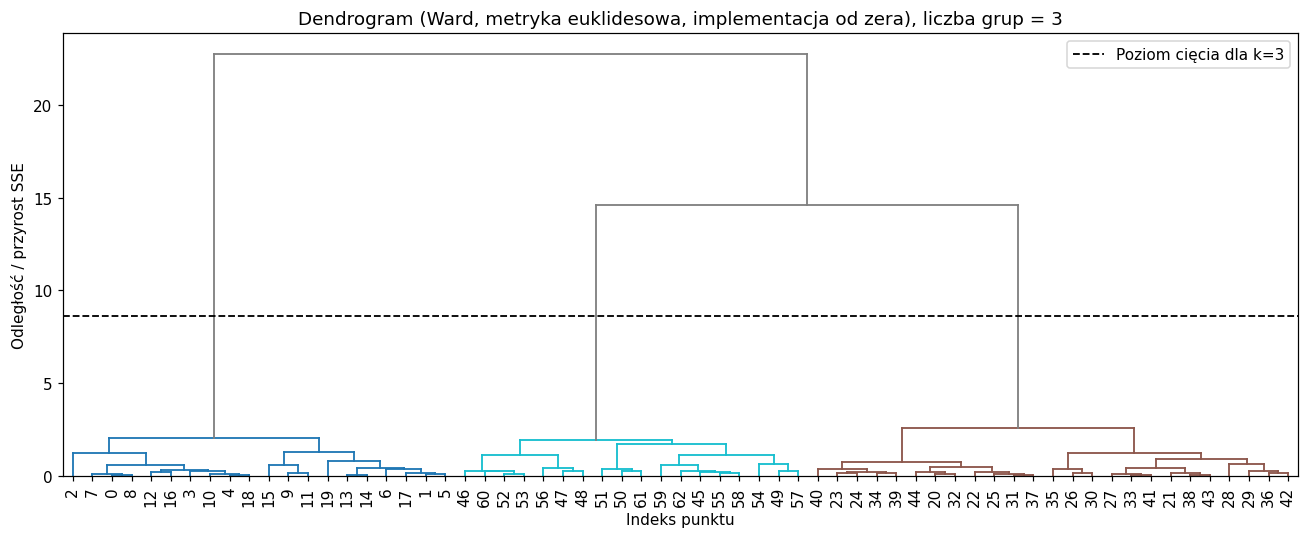

Liczba punktów: 63
Wektor etykiet (pierwsze 25): [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2]
Unikalne etykiety: [1 2 3]


In [4]:
rng = np.random.default_rng(42)

# Trzy skupiska 2D
cluster_a = rng.normal(loc=[-2.5, -1.0], scale=[0.45, 0.40], size=(20, 2))
cluster_b = rng.normal(loc=[2.0, 0.0], scale=[0.55, 0.35], size=(25, 2))
cluster_c = rng.normal(loc=[0.5, 3.0], scale=[0.40, 0.50], size=(18, 2))
X_demo = np.vstack([cluster_a, cluster_b, cluster_c])

n_clusters = 3
labels, Z = ward_hierarchical_clustering(X_demo, n_clusters=n_clusters, show_dendrogram=True)

print(f'Liczba punktów: {X_demo.shape[0]}')
print(f'Wektor etykiet (pierwsze 25): {labels[:25]}')
print(f'Unikalne etykiety: {np.unique(labels)}')

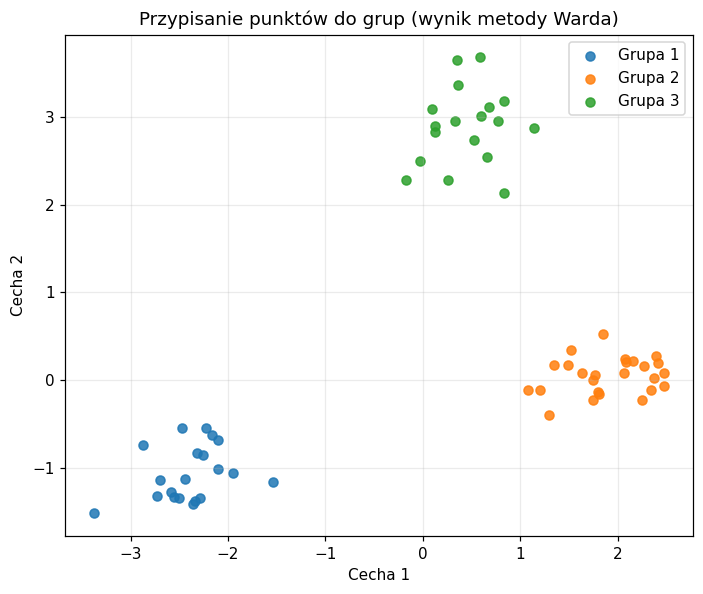

In [5]:
# Podgląd klastrów w 2D (dla danych demo)
plt.figure(figsize=(6.5, 5.5))
for group_id in np.unique(labels):
    mask = labels == group_id
    plt.scatter(X_demo[mask, 0], X_demo[mask, 1], s=35, alpha=0.85, label=f'Grupa {group_id}')

plt.title('Przypisanie punktów do grup (wynik metody Warda)')
plt.xlabel('Cecha 1')
plt.ylabel('Cecha 2')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Użycie na własnych danych

Podstaw swoją macierz `X` o kształcie `(n_prób, n_cech)` i ustaw liczbę grup.

In [6]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Użyj własnej macierzy X (n_prób, n_cech); jeśli jej nie ma, weźmiemy X_demo.
X_current = globals().get('X', None)
if X_current is None:
    if 'X_demo' not in globals():
        raise ValueError("Nie znaleziono zmiennej X ani X_demo. Zdefiniuj X i uruchom tę komórkę ponownie.")
    X_current = X_demo
    print("Uwaga: używam X_demo. Aby użyć własnych danych, zdefiniuj zmienną X (np. X = ...).")

X_current = np.asarray(X_current, dtype=float)
if X_current.ndim != 2 or X_current.shape[0] < 2:
    raise ValueError("X musi mieć kształt (n_prób, n_cech), gdzie n_prób >= 2.")

max_k = int(X_current.shape[0])
default_k = min(3, max_k)

k_slider = widgets.IntSlider(
    value=default_k,
    min=1,
    max=max_k,
    step=1,
    description='k:',
    continuous_update=False,
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='420px')
)

show_dend = widgets.Checkbox(
    value=True,
    description='Pokaż dendrogram',
    indent=False
)

run_btn = widgets.Button(description='Uruchom', button_style='primary')
output = widgets.Output()

def _run_clicked(_):
    with output:
        clear_output(wait=True)
        labels_local, Z_local = ward_hierarchical_clustering(
            X_current, n_clusters=k_slider.value, show_dendrogram=show_dend.value
        )
        print(f"Liczba punktów: {X_current.shape[0]}")
        print(f"Liczba cech: {X_current.shape[1]}")
        print(f"Wybrane k: {k_slider.value}")
        print(f"Unikalne etykiety: {np.unique(labels_local)}")

        # Zapis wyników do przestrzeni globalnej, żeby były dostępne w kolejnych komórkach.
        globals()['labels'] = labels_local
        globals()['Z'] = Z_local

        if X_current.shape[1] >= 2:
            plt.figure(figsize=(6.5, 5.5))
            for group_id in np.unique(labels_local):
                mask = labels_local == group_id
                plt.scatter(
                    X_current[mask, 0],
                    X_current[mask, 1],
                    s=35,
                    alpha=0.85,
                    label=f'Grupa {group_id}'
                )
            plt.title(f'Przypisanie punktów do grup (k={k_slider.value})')
            plt.xlabel('Cecha 1')
            plt.ylabel('Cecha 2')
            plt.legend()
            plt.grid(alpha=0.25)
            plt.tight_layout()
            plt.show()
        else:
            print('Wizualizacja 2D pominięta: dane mają mniej niż 2 cechy.')

run_btn.on_click(_run_clicked)

display(widgets.HBox([k_slider, show_dend, run_btn]))
display(output)

Uwaga: używam X_demo. Aby użyć własnych danych, zdefiniuj zmienną X (np. X = ...).


Output()